<img src="imagens/capa.jpg" width="100%">

<h1 style="font-size: 56px; font-weight: 900; letter-spacing: 0px; margin: 0;"><span style="color: rgb(166, 108, 255);">MODELO</span> DE RISCO DE CRÉDITO</h1>
<br>
<p>O presente trabalho utiliza o benchmark público <strong>German Credit</strong> para desenvolver um modelo que identifica quais clientes possuem probabilidade de "dar default", ou seja, não cumprir com suas obrigações em um contrato de empréstimo financeiro. O problema é de classificação binária, mas o que separa um classificador qualquer de um trabalho de risco de crédito é a higiene de validação, a interpretabilidade exigida por regulação e o custo assimétrico do erro. Aprovar um mau pagador custa o principal emprestado; reprovar um bom pagador custa uma margem. Os dois erros não valem o mesmo, e o modelo precisa refletir isso.

</p>
<br>
Ilustração de capa: Dmitrii Kharchenko.
<br>
<br>

<div style="background:#faf7ff;padding:6px 26px;margin:18px 0;">
<p style="font-weight:800;margin-bottom:4px;">ROTEIRO</p>
<ol style="color:#2D2A32;line-height:1.7;">
<li>Problema de negócio</li>
<li>Importando bibliotecas</li>
<li>Conjunto de dados</li>
<li>Análise exploratória</li>
<li>Qualidade dos dados e valores ausentes</li>
<li>Partição treino / teste</li>
<li>Weight of Evidence e Information Value</li>
<li>Pré-processamento como pipeline</li>
<li>Modelagem: baseline logístico e challenger XGBoost</li>
<li>Avaliação: ROC, KS, Gini, matriz de confusão e escolha de corte</li>
<li>Interpretação e scorecard (PDO)</li>
<li>Conclusão</li>
</ol></div>

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">1. PROBLEMA DE NEGÓCIO</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">
O <b>German Credit</b> reúne 1.000 solicitações de crédito descritas por atributos financeiros e
demográficos, cada uma rotulada como bom (<i>good</i>) ou mau (<i>bad</i>) pagador. A taxa de maus
é de cerca de 30%, o que torna a classe de interesse a <b>minoritária</b>, situação típica em
crédito e que exige cuidado tanto na modelagem quanto na leitura das métricas.</p>


<div style="background:#faf7ff;padding:6px 26px;margin:18px 0;">
<p style="font-weight:800;margin-bottom:4px;">CONVENÇÃO DO ALVO</p>
<ol style="color:#2D2A32;line-height:1.7;">
Codificamos <b>default = 1</b> (mau pagador) e <b>adimplente = 0</b>. A classe positiva é o evento que queremos capturar. Recall sobre a classe 1 é, portanto, a fração de inadimplentes que o modelo efetivamente captura.
</div>

<p style="font-size:15px;line-height:1.6;color:#2D2A32;">
Reguladores e áreas de risco exigem
<b>explicabilidade</b>: por que um cliente foi reprovado. Por isso o baseline aqui é uma
<b>regressão logística</b> e o XGBoost entra como <b>challenger</b>
para medir quanto de sinal não-linear está sendo deixado na mesa.</p>

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">2. IMPORTANDO BIBLIOTECAS</h1>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [2]:
# Cores: roxo (adimplente) x laranja (inadimplente)
PURPLE, PURPLE_L = "#7C3AED", "#A66CFF"
ORANGE, ORANGE_D = "#FB923C", "#EA580C"
INK = "#2D2A32"
PALETTE = {0: PURPLE, 1: ORANGE}          # 0 = good, 1 = default
SEQ = sns.blend_palette([PURPLE_L, PURPLE, "#4C1D95"], as_cmap=True)
DIV = sns.blend_palette([PURPLE, "#f2edff", ORANGE], as_cmap=True)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.labelcolor": INK, "axes.edgecolor": "#d9d3e8",
    "axes.grid": True, "grid.color": "#eee7fb", "grid.linewidth": .8,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

def ks_statistic(y_true, scores):
    fpr, tpr, _ = roc_curve(y_true, scores)
    return float(np.max(tpr - fpr))

def gini(y_true, scores):
    return 2 * roc_auc_score(y_true, scores) - 1

print("Ambiente pronto. Paleta roxo/laranja carregada.")

Ambiente pronto. Paleta roxo/laranja carregada.


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">3. CONJUNTO DE DADOS</h1>

In [3]:
credit = pd.read_csv("german_credit_data.csv").drop(columns=["Unnamed: 0"])
credit["default"] = (credit["Risk"] == "bad").astype(int)
print(f"Dimensões: {credit.shape[0]} solicitações x {credit.shape[1]} colunas")
print(f"Taxa de inadimplência: {credit['default'].mean():.1%}")
credit.head()

Dimensões: 1000 solicitações x 11 colunas
Taxa de inadimplência: 30.0%


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,good,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,1
2,49,male,1,own,little,NaN,2096,12,education,good,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,0
4,53,male,2,free,little,little,4870,24,car,bad,1


<strong>Metadados:</strong>

<strong>Age: </strong>	Idade do solicitante (anos)
<br><strong>Sex: </strong>		Sexo (male / female)
<br><strong>Job: </strong>		Qualificação profissional (0 a 3, ordinal)
<br><strong>Housing: </strong>		Moradia (own / rent / free)
<br><strong>Saving accounts: </strong>	Nível da poupança (little a rich)
<br><strong>Checking account: </strong>		Nível da conta corrente
<br><strong>Credit amount: </strong>		Valor do crédito solicitado (DM)
<br><strong>Duration: </strong>		Prazo do crédito (meses)
<br><strong>Purpose: </strong>		Finalidade do crédito
<br><strong>default: </strong>		Alvo: 1 = mau pagador, 0 = bom pagador




In [4]:
credit.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,1000,2,good,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">4. ANÁLISE EXPLORATÓRIA DE DADOS</h1>

## 4.1 VARIÁVEL ALVO

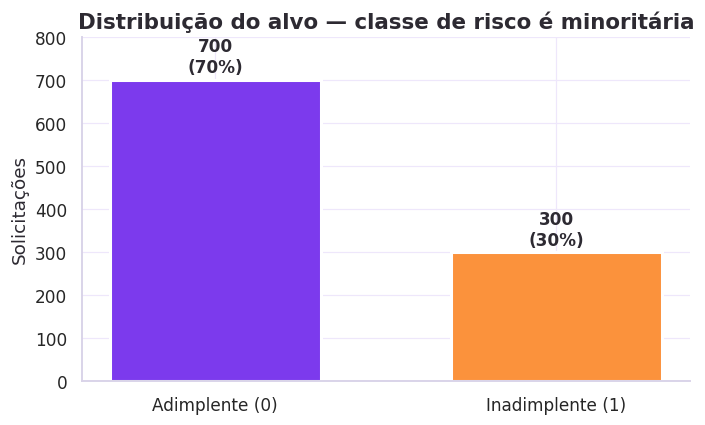

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
counts = credit["default"].value_counts().sort_index()
bars = ax.bar(["Adimplente (0)", "Inadimplente (1)"], counts.values,
              color=[PURPLE, ORANGE], width=.62, edgecolor="white", linewidth=2)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+8, f"{v}\n({v/len(credit):.0%})",
            ha="center", va="bottom", fontweight="bold", color=INK)
ax.set_title("Distribuição do alvo — classe de risco é minoritária")
ax.set_ylabel("Solicitações"); ax.set_ylim(0, 800)
sns.despine(); plt.tight_layout(); plt.show()

70/30 é um desbalanceamento moderado. Não é grave o suficiente para reamostragem agressiva, mas é grave o suficiente para que acurácia seja uma métrica enganosa: um modelo que chuta 'todo mundo bom' já acerta 70%. Vamos ancorar a avaliação em AUC, KS e recall da classe 1.

## 4.2 VARIÁVEIS NUMÉRICAS POR STATUS

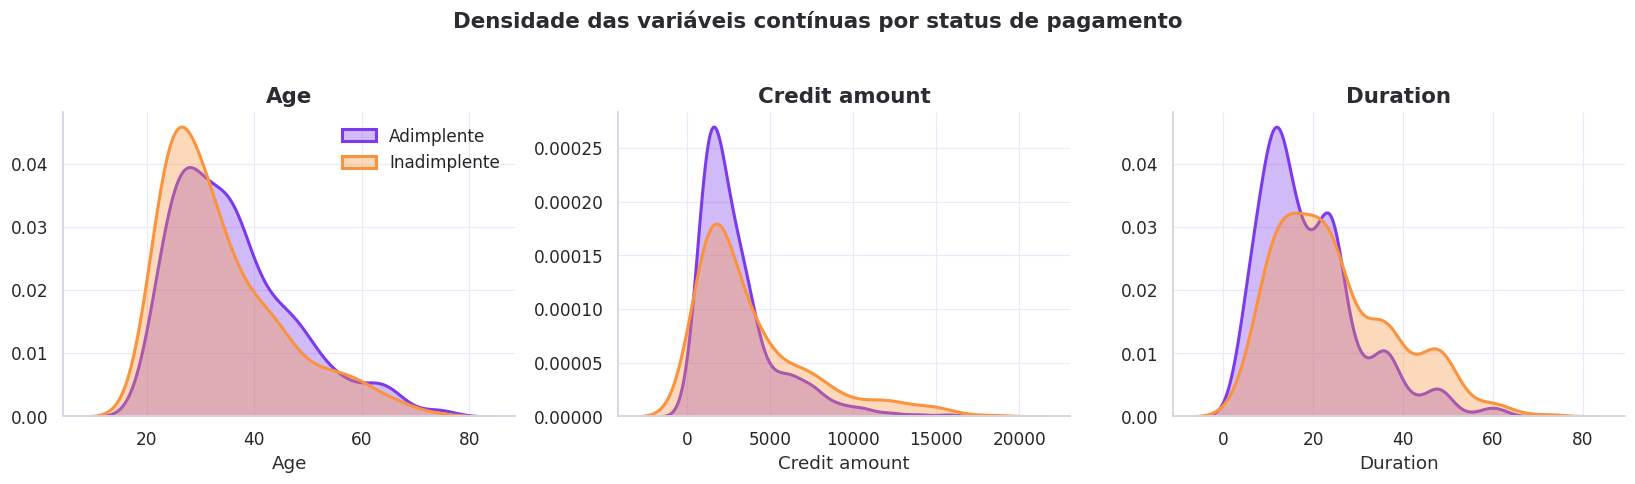

In [6]:
num_cols = ["Age", "Credit amount", "Duration"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, num_cols):
    for k, g in credit.groupby("default"):
        sns.kdeplot(g[col], ax=ax, fill=True, alpha=.35, linewidth=2,
                    color=PALETTE[k], label=("Inadimplente" if k else "Adimplente"))
    ax.set_title(col); ax.set_ylabel("")
axes[0].legend(frameon=False)
plt.suptitle("Densidade das variáveis contínuas por status de pagamento",
             fontsize=14, fontweight="bold", color=INK, y=1.04)
plt.tight_layout(); plt.show()

Duration e Credit amount deslocam-se para a direita entre inadimplentes: prazos longos e valores altos concentram os maiores riscos, o que é bastante intuitivo.

## 4.3 TAXA DE INADIMPLÊNCIA POR CATEGORIA

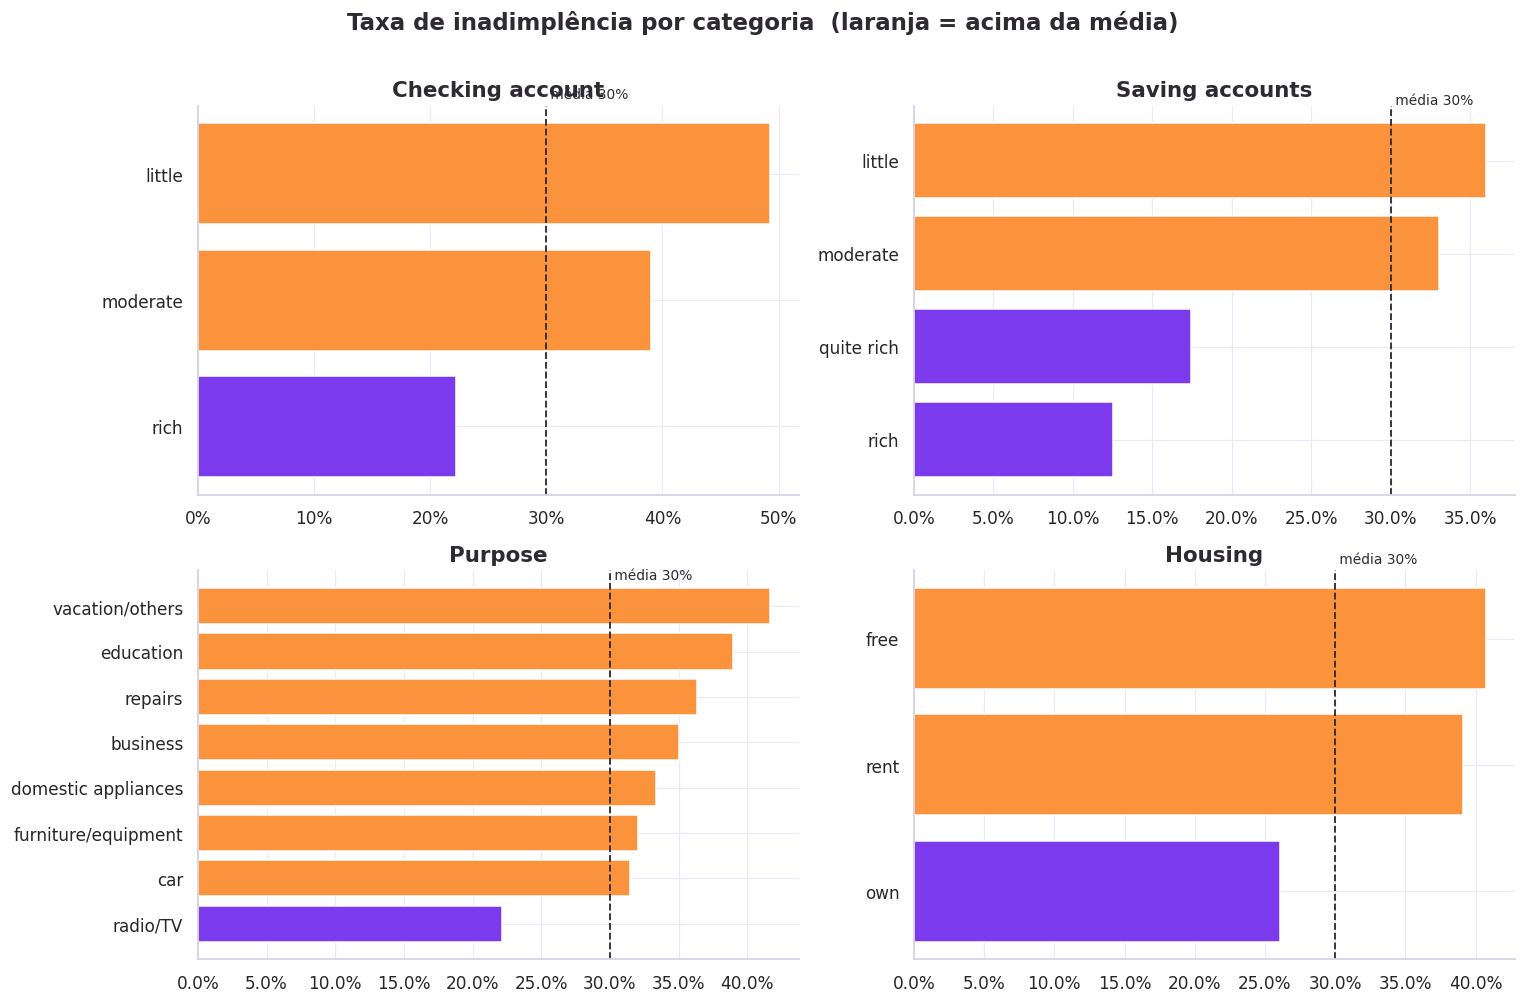

In [7]:
cat_plot = ["Checking account", "Saving accounts", "Purpose", "Housing"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
base_rate = credit["default"].mean()
for ax, col in zip(axes.ravel(), cat_plot):
    rate = credit.groupby(col)["default"].mean().sort_values(ascending=False)
    colors = [ORANGE if v >= base_rate else PURPLE for v in rate.values]
    ax.barh(rate.index.astype(str), rate.values, color=colors, edgecolor="white")
    ax.axvline(base_rate, color=INK, linestyle="--", linewidth=1.2)
    ax.text(base_rate, -0.6, f" média {base_rate:.0%}", color=INK, fontsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(col); ax.invert_yaxis()
plt.suptitle("Taxa de inadimplência por categoria  (laranja = acima da média)",
             fontsize=15, fontweight="bold", color=INK, y=1.01)
plt.tight_layout(); plt.show()

Checking account separa fortemente a variável alvo: clientes sem conta corrente registrada ('little' ou ausente) 'dão default' bem acima da média.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">5. QUALIDADE DOS DADOS E VALORES AUSENTES</h1>

In [8]:
missing = credit.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Colunas com ausentes:")
for c, v in missing.items():
    print(f"  {c:20s} {v:4d}  ({v/len(credit):.1%})")

Colunas com ausentes:
  Checking account      394  (39.4%)
  Saving accounts       183  (18.3%)


Em Saving accounts e Checking account, o ausente significa 'cliente não possui esse produto'. Tratar como categoria própria ('no_account') preserva informação, e veremos que a própria ausência é preditiva. Imputar pela moda apagaria sinal. A imputação será feita após o split, aprendendo só do treino.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">6. PARTIÇÃO TREINO / TESTE</h1>

Qualquer estatística usada para transformar os dados (imputação, WOE, escalonamento) precisa ser aprendida somente no treino e aplicada ao teste. Calcular WOE ou imputar usando o dataset inteiro é vazamento (data leakage) e infla as métricas. Por isso particionamos agora, de forma estratificada para preservar os 30% de default nos dois conjuntos.

In [9]:
cat_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]
num_cols = ["Age", "Credit amount", "Duration"]

X = credit[cat_cols + num_cols].copy()
y = credit["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Ausente = "não possui o produto": categoria informativa, não imputação
for c in ["Saving accounts", "Checking account"]:
    X_train[c] = X_train[c].fillna("no_account")
    X_test[c]  = X_test[c].fillna("no_account")
for c in cat_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c]  = X_test[c].astype(str)

print(f"Treino: {X_train.shape[0]}  |  default {y_train.mean():.1%}")
print(f"Teste : {X_test.shape[0]}  |  default {y_test.mean():.1%}")

Treino: 800  |  default 30.0%
Teste : 200  |  default 30.0%


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">7. WEIGHT OF EVIDENCE E INFORMATION VALUE</h1>

<p style="color:#2D2A32;line-height:1.6;">
O <b>Weight of Evidence</b> mede, para cada categoria, o quanto ela pende para bons ou maus
pagadores, na escala do log das chances:</p>
<p style="text-align:center;font-size:17px;color:#7C3AED;">
WoE = ln( %bons / %maus )&nbsp;&nbsp;&nbsp;&nbsp;
IV = &Sigma; ( %bons − %maus ) &times; WoE</p>
<p style="color:#2D2A32;line-height:1.6;">
O <b>Information Value</b> agrega o WoE numa nota única de poder preditivo. A régua clássica da
indústria: IV &lt; 0,02 inútil; 0,02–0,1 fraco; 0,1–0,3 médio; 0,3–0,5 forte; &gt; 0,5 suspeito de
vazamento. Calculamos tudo sobre as categorias cruas do treino.</p>

In [10]:
def woe_table(feature, target):
    """Tabela WoE/IV para uma variável categórica (categorias cruas)."""
    d = pd.DataFrame({"cat": feature.astype(str), "y": target.values})
    g = d.groupby("cat")["y"].agg(n="count", bad="sum")
    g["good"] = g["n"] - g["bad"]
    g["dist_good"] = g["good"] / g["good"].sum()
    g["dist_bad"]  = g["bad"]  / g["bad"].sum()
    g["bad_rate"]  = g["bad"] / g["n"]
    g["WoE"] = np.log((g["dist_good"] + 1e-6) / (g["dist_bad"] + 1e-6))
    g["IV_contrib"] = (g["dist_good"] - g["dist_bad"]) * g["WoE"]
    return g.sort_values("WoE"), g["IV_contrib"].sum()

def information_value(X, y, cats, nums, n_bins=5):
    ivs = {}
    for c in cats:
        _, iv = woe_table(X[c], y); ivs[c] = iv
    for c in nums:                       # numéricas: binning por quantil
        binned = pd.qcut(X[c], n_bins, duplicates="drop").astype(str)
        _, iv = woe_table(binned, y); ivs[c] = iv
    return pd.Series(ivs).sort_values(ascending=False)

iv_ranking = information_value(X_train, y_train, cat_cols, num_cols)
iv_ranking.round(4).to_frame("Information Value")

,Information Value
Checking account,0.6168
Saving accounts,0.2253
Duration,0.2171
Purpose,0.0918
Housing,0.0881
Credit amount,0.0665
Age,0.0437
Sex,0.0330
Job,0.0115


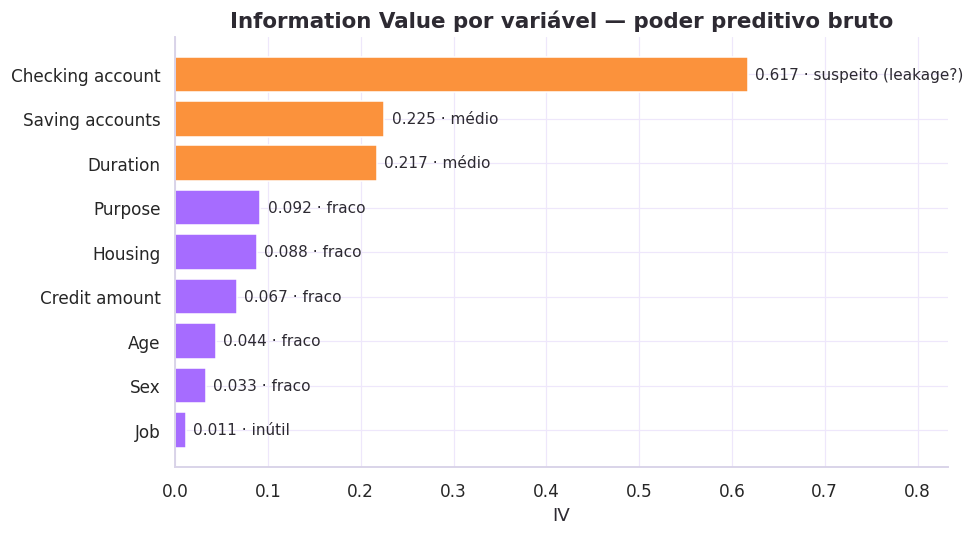

In [11]:
def iv_band(v):
    if v < 0.02:  return "inútil"
    if v < 0.10:  return "fraco"
    if v < 0.30:  return "médio"
    if v < 0.50:  return "forte"
    return "suspeito (leakage?)"

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ORANGE if v >= 0.10 else PURPLE_L for v in iv_ranking.values]
ax.barh(iv_ranking.index, iv_ranking.values, color=colors, edgecolor="white")
for i, (name, v) in enumerate(iv_ranking.items()):
    ax.text(v + .008, i, f"{v:.3f} · {iv_band(v)}", va="center", color=INK, fontsize=10)
ax.invert_yaxis(); ax.set_xlim(0, iv_ranking.max()*1.35)
ax.set_title("Information Value por variável — poder preditivo bruto")
ax.set_xlabel("IV"); sns.despine(); plt.tight_layout(); plt.show()

Checking account (IV ≈ 0,62) domina e beira o limiar de 'suspeito'. É uma variável genuinamente forte, já conhecida do benchmark do German Credit. Saving accounts e Duration ficam na faixa média. Job e Sex são quase inúteis (IV < 0,04), candidatos naturais a exclusão, e <b>no caso de Sex, também uma variável sensível que um modelo de crédito responsável evita. Portanto, ela será desconsiderada.</b>

In [12]:
# WoE detalhado da variável mais forte
woe_detail, iv_detail = woe_table(X_train["Checking account"], y_train)
print(f"Checking account — IV = {iv_detail:.4f}\n")
woe_detail[["n", "bad_rate", "WoE", "IV_contrib"]].round(3)

Checking account — IV = 0.6168



,n,bad_rate,WoE,IV_contrib
cat,,,,
little,219,0.479,-0.765,0.179
moderate,214,0.393,-0.411,0.048
rich,51,0.255,0.225,0.003
no_account,316,0.120,1.143,0.386


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">8. PRÉ-PROCESSAMENTO</h1>

In [13]:
# Removemos Sex por ser variável sensível e de IV desprezível
model_cats = [c for c in cat_cols if c != "Sex"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), model_cats),
    ("num", StandardScaler(), num_cols),
])
print("Categóricas no modelo:", model_cats)
print("Numéricas no modelo  :", num_cols)

Categóricas no modelo: ['Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Numéricas no modelo  : ['Age', 'Credit amount', 'Duration']


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">9. MODELAGEM: BASELINE E CHALLENGER</h1>

A <b>regressão logística</b> é o baseline interpretável que uma área de
risco consegue defender diante de um regulador. O <b>XGBoost</b> é o challenger que mede quanto de
estrutura não-linear existe. Ambos recebem correção de desbalanceamento
(<code>class_weight</code> / <code>scale_pos_weight</code>) para não ignorar a classe minoritária,
e ambos são avaliados por <b>validação cruzada estratificada</b> antes de qualquer olhar no teste.</p>

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()   # ~2.33

logit = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
xgb = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(n_estimators=250, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=scale_pos, eval_metric="auc",
                          random_state=RANDOM_STATE)),
])

results = []
for name, model in [("Regressão Logística", logit), ("XGBoost", xgb)]:
    auc_cv = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    p_test = model.predict_proba(X_test)[:, 1]
    results.append({
        "Modelo": name,
        "AUC (CV)": f"{auc_cv.mean():.3f} ± {auc_cv.std():.3f}",
        "AUC (teste)": roc_auc_score(y_test, p_test),
        "KS (teste)":  ks_statistic(y_test, p_test),
        "Gini (teste)": gini(y_test, p_test),
    })
res_df = pd.DataFrame(results).set_index("Modelo")
res_df.round(3)

,AUC (CV),AUC (teste),KS (teste),Gini (teste)
Modelo,,,,
Regressão Logística,0.740 ± 0.059,0.765,0.46,0.529
XGBoost,0.765 ± 0.053,0.770,0.44,0.541


O XGBoost ganha alguns pontos de AUC/Gini, mas a diferença é pequena e o intervalo de CV se sobrepõe. Em crédito, essa margem raramente compensa a perda de interpretabilidade e a complexidade de governança. Seguimos com a <b>logística como modelo campeão</b> e usamos o XGBoost como teto de referência.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">10. AVALIAÇÃO NO CONJUNTO DE TESTE</h1>

## 10.1 ROC E CURVA KS

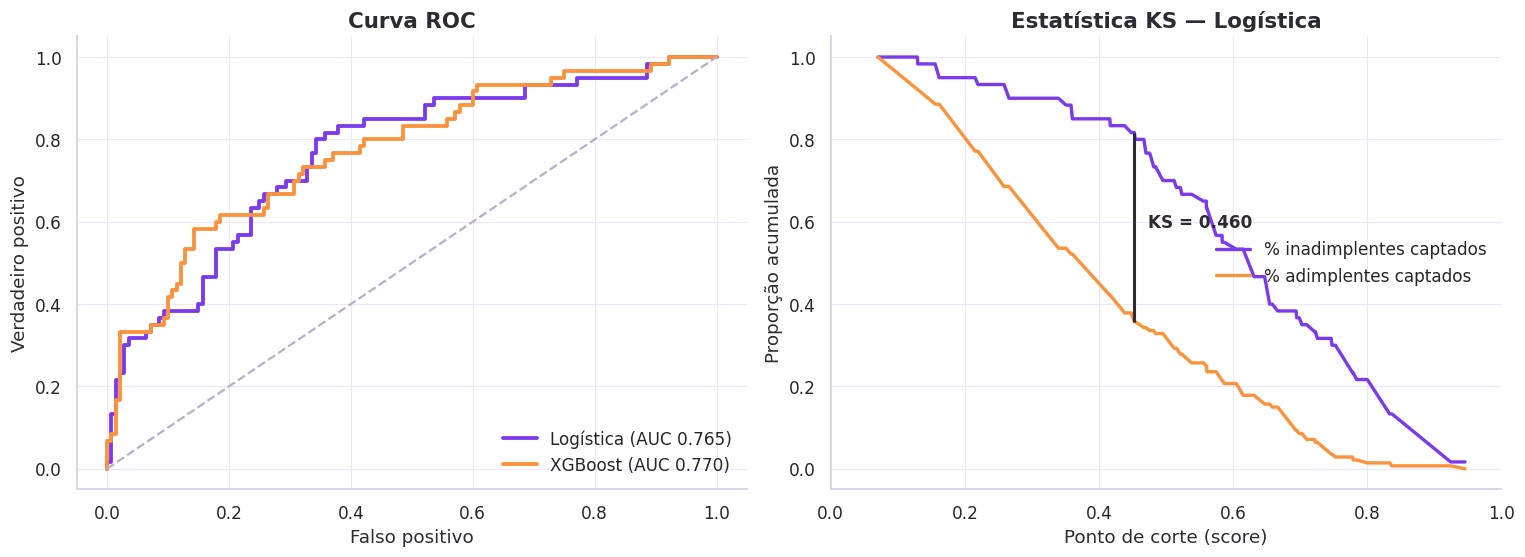

In [15]:
p_logit = logit.predict_proba(X_test)[:, 1]
p_xgb   = xgb.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

# --- ROC ---
for p, name, c in [(p_logit, "Logística", PURPLE), (p_xgb, "XGBoost", ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax1.plot(fpr, tpr, color=c, linewidth=2.5,
             label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
ax1.plot([0, 1], [0, 1], "--", color="#b8b0cc")
ax1.set_xlabel("Falso positivo"); ax1.set_ylabel("Verdadeiro positivo")
ax1.set_title("Curva ROC"); ax1.legend(frameon=False, loc="lower right")

# --- KS ---
fpr, tpr, thr = roc_curve(y_test, p_logit)
ks_idx = np.argmax(tpr - fpr)
ax2.plot(thr, tpr, color=PURPLE, linewidth=2.2, label="% inadimplentes captados")
ax2.plot(thr, fpr, color=ORANGE, linewidth=2.2, label="% adimplentes captados")
ax2.vlines(thr[ks_idx], fpr[ks_idx], tpr[ks_idx], color=INK, linewidth=2)
ax2.text(thr[ks_idx]+.02, (tpr[ks_idx]+fpr[ks_idx])/2,
         f"KS = {tpr[ks_idx]-fpr[ks_idx]:.3f}", fontweight="bold", color=INK)
ax2.set_xlim(0, 1); ax2.set_xlabel("Ponto de corte (score)"); ax2.set_ylabel("Proporção acumulada")
ax2.set_title("Estatística KS — Logística"); ax2.legend(frameon=False, loc="center right")
plt.tight_layout(); plt.show()

## 10.2 MATRIZ DE CONFUSÃO E ESCOLHA DO CORTE
O corte padrão de 0,50 não é sagrado. Como reprovar um bom pagador custa margem e aprovar um mau custa o principal, o corte deve refletir esse custo. Abaixo comparamos 0,50 com um corte mais conservador que prioriza capturar inadimplentes (recall da classe 1), aceitando reprovar mais bons pagadores em troca.

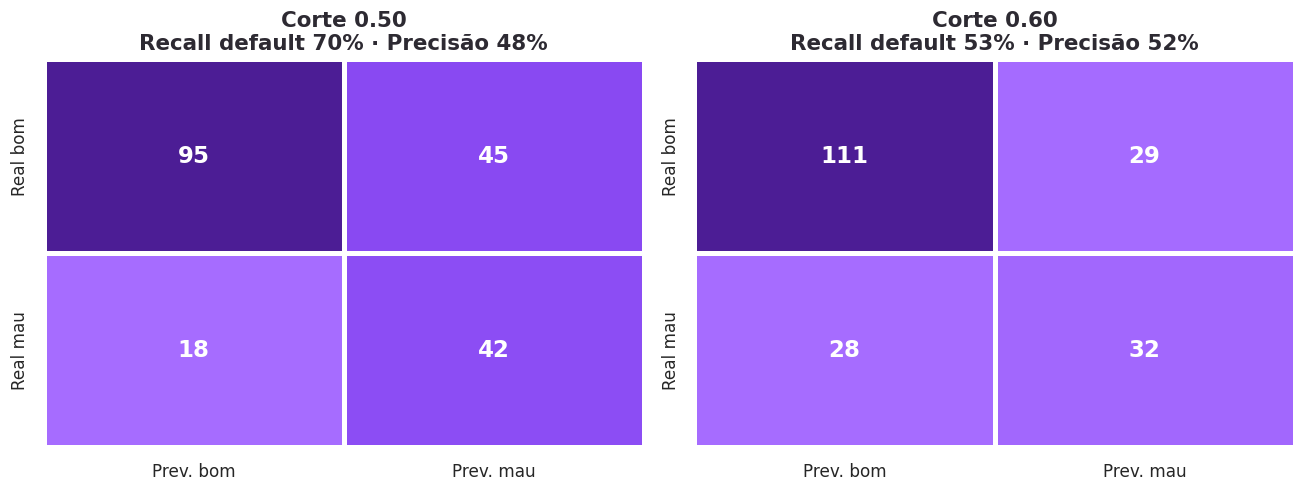

              precision    recall  f1-score   support

  Adimplente      0.841     0.679     0.751       140
Inadimplente      0.483     0.700     0.571        60

    accuracy                          0.685       200
   macro avg      0.662     0.689     0.661       200
weighted avg      0.733     0.685     0.697       200



In [16]:
def confusion_at(threshold, ax):
    pred = (p_logit >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=SEQ, cbar=False, ax=ax,
                annot_kws={"size": 15, "weight": "bold"},
                xticklabels=["Prev. bom", "Prev. mau"],
                yticklabels=["Real bom", "Real mau"], linewidths=2, linecolor="white")
    rec = cm[1, 1] / cm[1].sum()
    prec = cm[1, 1] / cm[:, 1].sum() if cm[:, 1].sum() else 0
    ax.set_title(f"Corte {threshold:.2f}\nRecall default {rec:.0%} · Precisão {prec:.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
confusion_at(0.50, axes[0])
confusion_at(0.60, axes[1])
plt.tight_layout(); plt.show()

print(classification_report(y_test, (p_logit >= 0.50).astype(int),
      target_names=["Adimplente", "Inadimplente"], digits=3))

Com balanceamento de classes, <b>o modelo captura cerca de sete em cada dez inadimplentes</b> no corte de 0,50. O preço é maior taxa de falsos positivos (bons pagadores reprovados). Onde exatamente cravar o corte é decisão de política de crédito, calibrada pela matriz de custo real da instituição, não pelo default do sklearn.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">11. INTERPRETAÇÃO E SCORECARD (PDO)</h1>

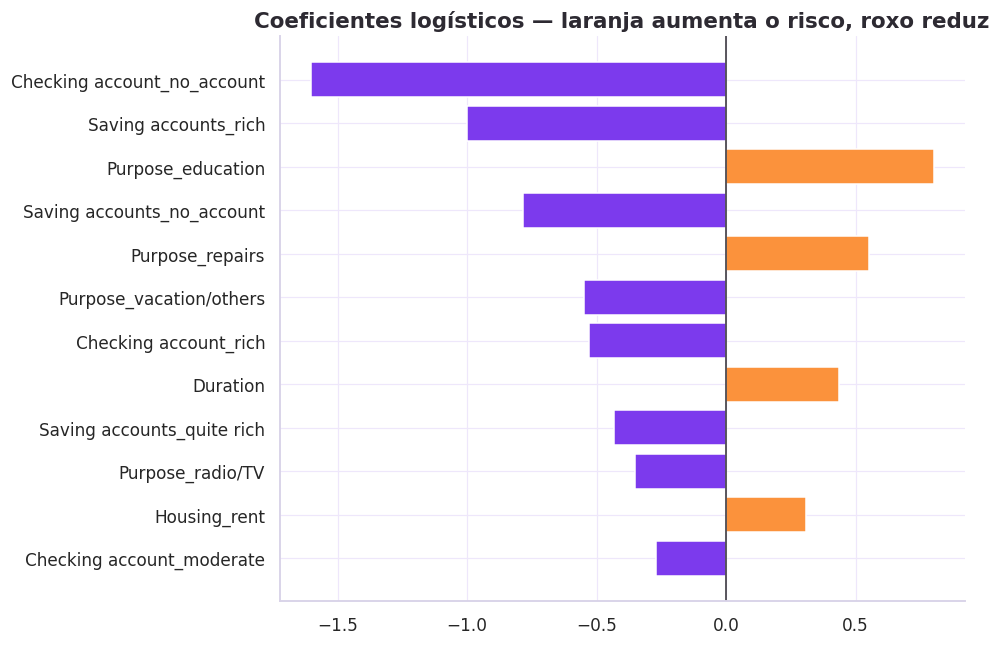

,variavel,coeficiente,odds_ratio
10,cat__Checking account_no_account,-1.603,0.201
8,cat__Saving accounts_rich,-1.000,0.368
14,cat__Purpose_education,0.801,2.228
6,cat__Saving accounts_no_account,-0.783,0.457
17,cat__Purpose_repairs,0.552,1.737
18,cat__Purpose_vacation/others,-0.548,0.578
11,cat__Checking account_rich,-0.529,0.589
21,num__Duration,0.437,1.548
7,cat__Saving accounts_quite rich,-0.432,0.649
16,cat__Purpose_radio/TV,-0.352,0.703


In [17]:
feat_names = logit.named_steps["prep"].get_feature_names_out()
coefs = logit.named_steps["clf"].coef_[0]
coef_tbl = (pd.DataFrame({"variavel": feat_names, "coeficiente": coefs})
            .assign(odds_ratio=lambda d: np.exp(d["coeficiente"]))
            .sort_values("coeficiente", key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = coef_tbl.head(12).iloc[::-1]
colors = [ORANGE if c > 0 else PURPLE for c in top["coeficiente"]]
ax.barh(top["variavel"].str.replace("cat__|num__", "", regex=True),
        top["coeficiente"], color=colors, edgecolor="white")
ax.axvline(0, color=INK, linewidth=1)
ax.set_title("Coeficientes logísticos — laranja aumenta o risco, roxo reduz")
sns.despine(); plt.tight_layout(); plt.show()
coef_tbl.head(10).round(3)

<p style="color:#2D2A32;line-height:1.6;">
Um scorecard traduz a probabilidade em <b>pontos</b>, calibrados por dois parâmetros da indústria:
o <b>PDO</b> (points to double the odds — de quantos pontos as chances dobram) e um score de
referência. A fórmula usa <code>factor = PDO / ln(2)</code> e <code>offset = score − factor·ln(odds)</code>,
convertendo o log-odds do modelo numa escala legível de negócio.</p>

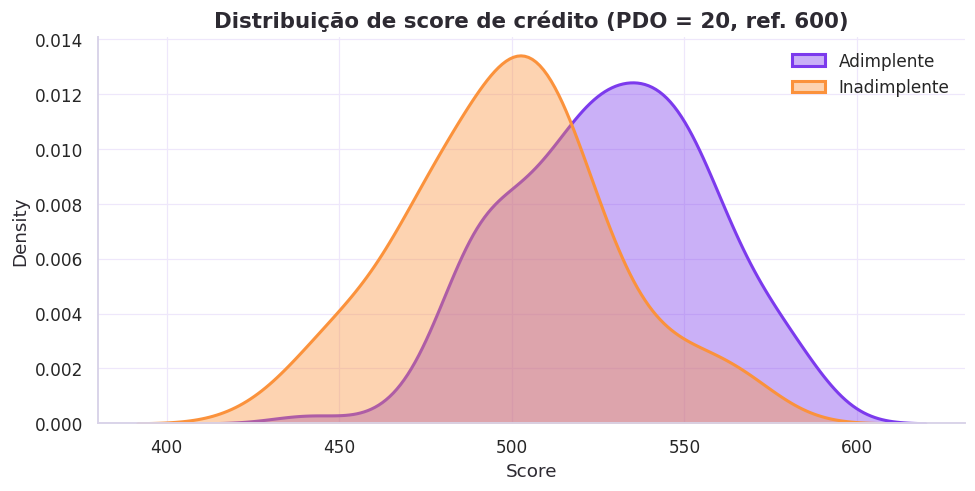

Score médio — adimplentes: 528  |  inadimplentes: 499


In [18]:
def to_scorecard(prob, target_score=600, target_odds=20, pdo=20):
    factor = pdo / np.log(2)
    offset = target_score - factor * np.log(target_odds)
    odds = (1 - prob) / prob            # odds de ser bom pagador
    return offset + factor * np.log(odds)

scores = to_scorecard(p_logit)
fig, ax = plt.subplots(figsize=(9, 4.6))
for k, g in pd.DataFrame({"score": scores, "y": y_test.values}).groupby("y"):
    sns.kdeplot(g["score"], ax=ax, fill=True, alpha=.4, linewidth=2,
                color=PALETTE[k], label=("Inadimplente" if k else "Adimplente"))
ax.set_title("Distribuição de score de crédito (PDO = 20, ref. 600)")
ax.set_xlabel("Score"); ax.legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()
print(f"Score médio — adimplentes: {scores[y_test.values==0].mean():.0f}"
      f"  |  inadimplentes: {scores[y_test.values==1].mean():.0f}")

O score nada mais é do que a probabilidade estimada pelo modelo traduzida para uma escala de pontos, do tipo que todo mundo reconhece quando ouve falar em 'score de crédito'. O gráfico traz duas curvas, uma para cada grupo. A dos bons pagadores fica deslocada para a direita, ou seja, eles acumulam pontuações mais altas; a dos inadimplentes fica mais à esquerda, em pontuações baixas. Quanto mais afastadas as duas curvas, melhor o modelo separa quem paga de quem não paga. Na operação, a mesa de crédito traça uma linha de corte nessa régua: acima dela aprova, abaixo reprova. Dizer 'score 540' é muito mais fácil de operar e de explicar ao cliente do que dizer 'probabilidade de inadimplência de 0,23', ainda que as duas frases carreguem exatamente a mesma informação.

## DATAFRAME FINAL
Uma linha por cliente do conjunto de teste, juntando os atributos originais às saídas do modelo: a probabilidade de inadimplência, o score em pontos e a decisão no corte de 0,50. É a visão que uma mesa de crédito consulta para decidir caso a caso.

In [19]:
resultado = X_test.copy()
resultado["y_real"] = y_test.values
resultado["prob_default"] = p_logit
resultado["score"] = scores
resultado["decisao_corte_050"] = (p_logit >= 0.50).astype(int)
resultado.sort_values("prob_default", ascending=False).head(10)

,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Age,Credit amount,Duration,y_real,prob_default,score,decisao_corte_050
938,male,2,free,little,moderate,education,42,6288,60,1,0.945898,431.002667,1
395,male,2,rent,moderate,moderate,education,32,11760,39,0,0.924536,441.264046,1
788,male,2,free,little,moderate,education,50,6224,48,1,0.913510,445.544975,1
11,female,2,rent,little,little,business,24,4308,48,1,0.908889,447.193463,1
832,male,2,rent,little,little,business,29,11816,45,1,0.904806,448.588132,1
375,female,2,rent,little,little,business,37,7685,48,1,0.904570,448.666962,1
677,male,2,own,moderate,moderate,radio/TV,24,5595,72,1,0.880621,455.901903,1
522,male,2,free,little,little,furniture/equipment,53,7119,48,1,0.857874,461.689586,1
887,male,2,own,little,moderate,business,23,15672,48,1,0.836956,466.363563,1
43,male,2,rent,moderate,little,car,24,6187,30,0,0.833520,467.083999,1


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px; ">12. CONCLUSÃO</h1>

O modelo campeão é uma regressão logística com correção de desbalanceamento, escolhida pela interpretabilidade que uma área de crédito precisa defender diante de um regulador. No conjunto de teste ela alcança AUC 0,77, KS 0,46 e Gini 0,53, e captura cerca de 70% dos inadimplentes no corte de 0,50. O XGBoost, usado como challenger, entrega ganho marginal (Gini 0,54) que não compensa a perda de transparência.
O pipeline foi construído sem vazamento: a partição precede qualquer transformação, e imputação, WOE e escalonamento aprendem apenas do treino. A seleção de variáveis seguiu o Information Value, com Checking account e Saving accounts no topo, e Sex foi descartada por ser sensível e pouco preditiva.
<br>
<br>
Limitações: são 1.000 observações, o que alarga os intervalos das métricas; o dataset é estático, sem safra temporal para medir estabilidade populacional (PSI) ou deriva; e o corte usado é ilustrativo, não calibrado por uma matriz de custo real.
Próximos passos: calibração de probabilidade para uso sob IFRS 9, scorecard pontuado célula a célula via WOE encoding, monitoramento por PSI e uma curva de custo que fixe o ponto de corte pela economia real da carteira.